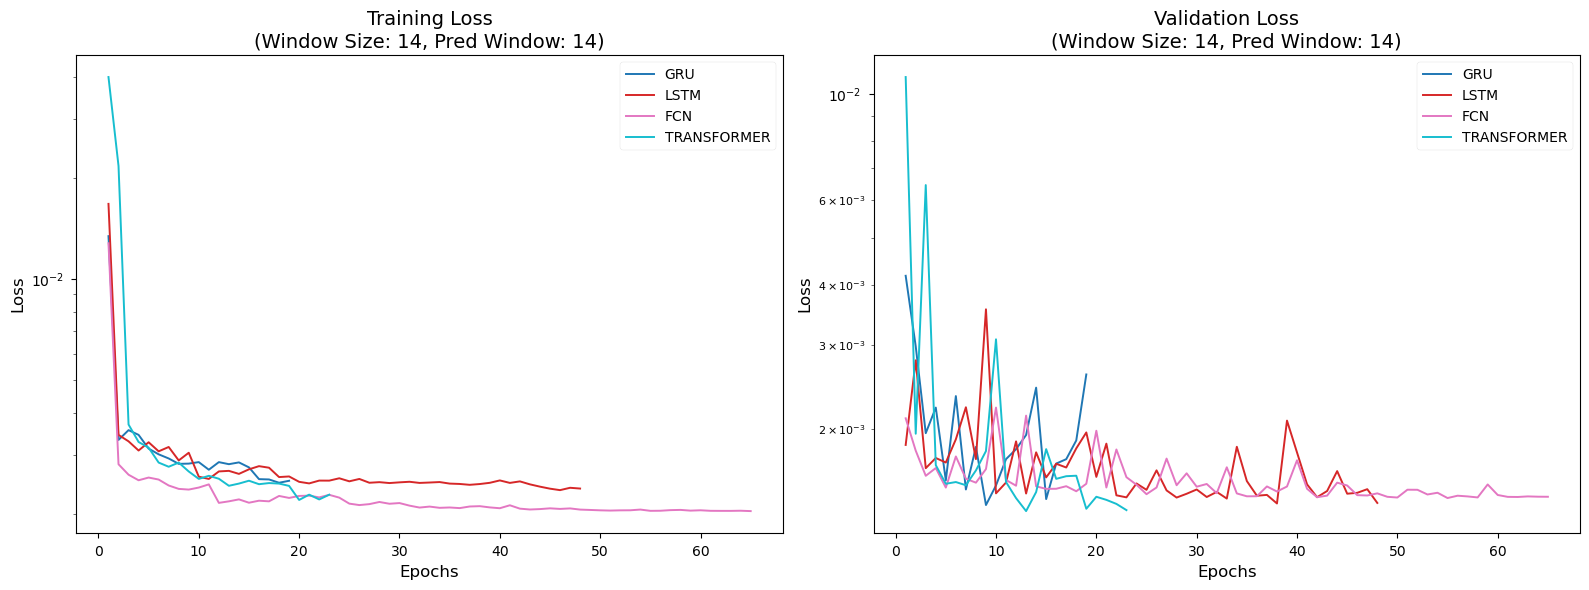

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_losses(loss_save_path, window_size, pred_window, model_types):
    # Set up plot style
    plt.style.use('seaborn-v0_8-paper')
    colors = plt.cm.tab10(np.linspace(0, 1, len(model_types)))

    # Create separate plots for training and validation losses
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    for model_type, color in zip(model_types, colors):
        train_loss = np.load(os.path.join(loss_save_path, f"{model_type}_train_loss_10km_lrschd_{window_size}_{pred_window}.npy"))
        val_loss = np.load(os.path.join(loss_save_path, f"{model_type}_val_loss_10km_lrschd_{window_size}_{pred_window}.npy"))
        
        epochs = range(1, len(train_loss) + 1)
        
        # Plot training loss
        ax1.semilogy(epochs, train_loss, label=f'{model_type.upper()}', color=color)
        
        # Plot validation loss
        ax2.semilogy(epochs, val_loss, label=f'{model_type.upper()}', color=color)

    # Configure training loss plot
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title(f'Training Loss\n(Window Size: {window_size}, Pred Window: {pred_window})', fontsize=14)
    ax1.legend(fontsize=10)
    ax1.set_yscale('log')
    ax1.tick_params(axis='both', which='major', labelsize=10)

    # Configure validation loss plot
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title(f'Validation Loss\n(Window Size: {window_size}, Pred Window: {pred_window})', fontsize=14)
    ax2.legend(fontsize=10)
    ax2.set_yscale('log')
    ax2.tick_params(axis='both', which='major', labelsize=10)

    plt.tight_layout()
    plt.savefig(f'losses_plot_{window_size}_{pred_window}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Usage
loss_save_path = '/projects/bcnx/jpyoo/summer/many_to_many/loss_history'
window_size = 14  # Replace with your actual window size
pred_window = 14   # Replace with your actual prediction window
model_types = ['gru', 'lstm', 'fcn', 'transformer']

plot_losses(loss_save_path, window_size, pred_window, model_types)

In [2]:
def compute_relative_l2_error_per_channel(preds, targets):
    """Compute relative L2 error per sample for each channel."""
    batch_size, channels, spatial_points, time_steps = preds.shape
    
    # Reshape to (batch_size, channels, -1) for easier computation
    preds_reshaped = preds.reshape(batch_size, channels, -1)
    targets_reshaped = targets.reshape(batch_size, channels, -1)
    
    errors = {}
    for c in range(channels):
        numerator = np.linalg.norm(preds_reshaped[:, c, :] - targets_reshaped[:, c, :], axis=1)
        denominator = np.linalg.norm(targets_reshaped[:, c, :], axis=1)
        errors[f'channel_{c}'] = numerator / (denominator + 1e-8)
    
    return errors

def compute_rmse_per_channel(preds, targets):
    """Compute RMSE per sample for each channel."""
    batch_size, channels, spatial_points, time_steps = preds.shape
    
    preds_reshaped = preds.reshape(batch_size, channels, -1)
    targets_reshaped = targets.reshape(batch_size, channels, -1)
    
    rmse = {}
    for c in range(channels):
        mse = np.mean((preds_reshaped[:, c, :] - targets_reshaped[:, c, :]) ** 2, axis=1)
        rmse[f'channel_{c}'] = np.sqrt(mse)
    
    return rmse

def compute_mae_per_channel(preds, targets):
    """Compute MAE per sample for each channel."""
    batch_size, channels, spatial_points, time_steps = preds.shape
    
    preds_reshaped = preds.reshape(batch_size, channels, -1)
    targets_reshaped = targets.reshape(batch_size, channels, -1)
    
    mae = {}
    for c in range(channels):
        mae[f'channel_{c}'] = np.mean(np.abs(preds_reshaped[:, c, :] - targets_reshaped[:, c, :]), axis=1)
    
    return mae

def compute_average_scores(preds, targets):
    """Compute average scores across all metrics for each channel."""
    rel_l2_errors = compute_relative_l2_error_per_channel(preds, targets)
    rmse_errors = compute_rmse_per_channel(preds, targets)
    mae_errors = compute_mae_per_channel(preds, targets)
    
    avg_scores = {}
    channels = preds.shape[1]
    
    for c in range(channels):
        channel_key = f'channel_{c}'
        avg_scores[channel_key] = {
            'avg_rel_l2': np.mean(rel_l2_errors[channel_key]),
            'avg_rmse': np.mean(rmse_errors[channel_key]),
            'avg_mae': np.mean(mae_errors[channel_key]),
            'std_rel_l2': np.std(rel_l2_errors[channel_key]),
            'std_rmse': np.std(rmse_errors[channel_key]),
            'std_mae': np.std(mae_errors[channel_key])
        }
    
    return avg_scores

def print_detailed_statistics(preds, targets):
    """Print detailed statistics for each channel."""
    avg_scores = compute_average_scores(preds, targets)
    channels = preds.shape[1]
    
    print("="*80)
    print("DETAILED STATISTICS BY CHANNEL")
    print("="*80)
    
    for c in range(channels):
        channel_key = f'channel_{c}'
        scores = avg_scores[channel_key]
        
        print(f"\nChannel {c} Statistics:")
        print("-" * 40)
        print(f"Relative L2 Error: {scores['avg_rel_l2']:.6f} ± {scores['std_rel_l2']:.6f}")
        print(f"RMSE:             {scores['avg_rmse']:.6f} ± {scores['std_rmse']:.6f}")
        print(f"MAE:              {scores['avg_mae']:.6f} ± {scores['std_mae']:.6f}")
    
    # Overall statistics
    print(f"\nOverall Statistics (All Channels):")
    print("-" * 40)
    overall_rel_l2 = np.mean([avg_scores[f'channel_{c}']['avg_rel_l2'] for c in range(channels)])
    overall_rmse = np.mean([avg_scores[f'channel_{c}']['avg_rmse'] for c in range(channels)])
    overall_mae = np.mean([avg_scores[f'channel_{c}']['avg_mae'] for c in range(channels)])
    
    print(f"Average R-L2:              {overall_rel_l2:.6f}")
    print(f"Average RMSE:              {overall_rmse:.6f}")
    print(f"Average MAE:               {overall_mae:.6f}")
    print("="*80)

In [3]:
import seaborn as sns
from scipy import stats

def load_results(model_type, window_size, pred_window, save_path):
    preds = np.load(f'{save_path}/{model_type}_predictions_{window_size}_{pred_window}.npy')
    targets = np.load(f'{save_path}/{model_type}_targets_{window_size}_{pred_window}.npy')
    return preds, targets

def plot_error_distribution(model_type, window_size, pred_window, save_path, preds, targets, error_type='rel_l2', figsize=(16, 16)):
    """Plot the distribution of errors for each channel."""   
    if error_type == 'rel_l2':
        errors = compute_relative_l2_error_per_channel(preds, targets)
    elif error_type == 'rmse':
        errors = compute_rmse_per_channel(preds, targets)
    elif error_type == 'mae':
        errors = compute_mae_per_channel(preds, targets)
    else:
        raise ValueError("Invalid error_type. Choose 'rel_l2', 'rmse', or 'mae'.")

    channels = preds.shape[1]
    rows = int(np.ceil(np.sqrt(channels)))
    cols = rows
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()  # Flatten the 2D array of axes for easy indexing
    
    # Determine global min and max for x and y axes
    all_errors = np.concatenate([errors[f'channel_{c}'] for c in range(channels)])
    x_min, x_max = np.min(all_errors), np.max(all_errors)
    y_max = 0
    
    # First pass to determine y_max
    for c in range(channels):
        channel_key = f'channel_{c}'
        counts, _ = np.histogram(errors[channel_key], bins='auto', density=True)
        y_max = max(y_max, np.max(counts))
    
    for c in range(channels):
        channel_key = f'channel_{c}'
        sns.histplot(errors[channel_key], kde=True, ax=axes[c])
        axes[c].set_title(f'Channel {c}')
        axes[c].set_xlabel(error_type.upper())
        
        # Set uniform x and y axes
        axes[c].set_xlim(x_min, x_max)
        axes[c].set_ylim(1, y_max)  # Start from 1 for log scale
        
        # Set y-axis to logarithmic scale
        axes[c].set_yscale('log')
        
        # Add grid for better readability
        axes[c].grid(True, which="both", ls="-", alpha=0.2)
    
    # Hide any unused subplots
    for i in range(channels, len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle(f'{model_type.upper()} - {error_type.upper()} Distribution')
    plt.tight_layout()
    plt.savefig(f'{save_path}/{model_type}_{error_type}_distribution_{window_size}_{pred_window}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_prediction_vs_target(model_type, window_size, pred_window, save_path, preds, targets, random_indices, channel=0, figsize=(15, 15)):
    num_samples = len(random_indices)
    fig, axes = plt.subplots(num_samples, 2, figsize=figsize)
    
    for i, idx in enumerate(random_indices):
        pred = preds[idx, channel, :, 0]
        target = targets[idx, channel, :, 0]
        
        # Plot 1: Prediction and Target
        axes[i, 0].plot(target, label='Target', alpha=0.7)
        axes[i, 0].plot(pred, label='Prediction', alpha=0.7)
        axes[i, 0].set_title(f'Sample {idx} - Prediction and Target')
        axes[i, 0].legend()
        axes[i, 0].set_xlabel('Spatial Points')
        axes[i, 0].set_ylabel('Value')
        
        # Plot 2: Difference and Scatter
        axes[i, 1].plot(pred - target, label='Difference', color='r', alpha=0.7)
        axes[i, 1].scatter(range(len(pred)), pred - target, s=10, alpha=0.5)
        axes[i, 1].axhline(y=0, color='k', linestyle='--')
        axes[i, 1].set_title(f'Sample {idx} - Difference (Prediction - Target)')
        axes[i, 1].legend()
        axes[i, 1].set_xlabel('Spatial Points')
        axes[i, 1].set_ylabel('Difference')
        
    plt.suptitle(f'{model_type.upper()} - Prediction vs Target (Channel {channel})')
    plt.tight_layout()
    plt.savefig(f'{save_path}/{model_type}_prediction_vs_target_channel_{channel}_{window_size}_{pred_window}.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_error_heatmap(model_type, window_size, pred_window, save_path, preds, targets, channel=0, figsize=(12, 8)):
    
    error = np.abs(preds[:, channel, :, 0] - targets[:, channel, :, 0])
    
    plt.figure(figsize=figsize)
    sns.heatmap(error, cmap='YlOrRd')
    plt.title(f'{model_type.upper()} - Absolute Error Heatmap (Channel {channel})')
    plt.xlabel('Spatial Points')
    plt.ylabel('Samples')
    plt.tight_layout()
    plt.savefig(f'{save_path}/{model_type}_error_heatmap_channel_{channel}_{window_size}_{pred_window}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:

# Usage
save_path = '/plots'
result_path = '/inference_results'
model_types = ['fcn', 'lstm', 'gru', 'transformer']
window_size = 14
pred_window = 14
num_samples = 3  # Number of random samples to visualize
for model_type in model_types:
    np.random.seed(42)  # For reproducibility
    # Load predictions and targets
    pred, target = load_results(model_type, window_size, pred_window, result_path)
    batch_size = pred.shape[0]
    random_indices = np.random.choice(batch_size, num_samples, replace=False)
    # Compute and print detailed statistics
    print_detailed_statistics(pred, target)
    # plot_error_distribution(model_type, window_size, pred_window, save_path, pred, target, error_type='rel_l2')
    # plot_prediction_vs_target(model_type, window_size, pred_window, save_path, pred, target, random_indices, channel=0)
    # plot_prediction_vs_target(model_type, window_size, pred_window, save_path, pred, target, random_indices, channel=13)
    # plot_error_heatmap(model_type, window_size, pred_window, save_path, pred, target, channel=0)
    # plot_error_heatmap(model_type, window_size, pred_window, save_path, pred, target, channel=13)

DETAILED STATISTICS BY CHANNEL

Channel 0 Statistics:
----------------------------------------
Relative L2 Error: 0.014961 ± 0.011341
RMSE:             0.048945 ± 0.035500
MAE:              0.035754 ± 0.028156

Channel 1 Statistics:
----------------------------------------
Relative L2 Error: 0.020144 ± 0.015623
RMSE:             0.065902 ± 0.049225
MAE:              0.049984 ± 0.039769

Channel 2 Statistics:
----------------------------------------
Relative L2 Error: 0.024331 ± 0.018069
RMSE:             0.079661 ± 0.057193
MAE:              0.061543 ± 0.046355

Channel 3 Statistics:
----------------------------------------
Relative L2 Error: 0.027299 ± 0.020533
RMSE:             0.089510 ± 0.065222
MAE:              0.069846 ± 0.053117

Channel 4 Statistics:
----------------------------------------
Relative L2 Error: 0.029545 ± 0.021983
RMSE:             0.097052 ± 0.070324
MAE:              0.076076 ± 0.057529

Channel 5 Statistics:
----------------------------------------
Relative L

In [ ]:
data_path = '/path/Cosmic10000/data'

target_file = 'dose/combined.npy'
branch_file = 'neutron/neutron_data_2001_2023.npy'
trunc_file = 'coord/grid_array.npy'

def convert2dim(dose_array):
    # laod the grid_array
    grid_array = np.load(os.path.join(data_path,trunc_file))

    # Sort grid_array by latitude first (column 0), then by longitude (column 1)
    sorted_indices = np.lexsort((grid_array[:, 0], grid_array[:, 1]))
    sorted_grid_array = grid_array[sorted_indices]
    sorted_dose_array = dose_array[sorted_indices]
    
    # Extract unique latitude and longitude values from the sorted grid array
    latitudes = np.unique(sorted_grid_array[:, 1])  # Extract unique latitude values (y-axis)
    longitudes = np.unique(sorted_grid_array[:, 0])  # Extract unique longitude values (x-axis)

    # Create a meshgrid with (longitude, latitude) to match the correct order
    lon_grid, lat_grid = np.meshgrid(longitudes, latitudes)

    # Ensure the sorted dose_array is reshaped correctly to match the meshgrid dimensions
    z = sorted_dose_array.reshape(len(latitudes), len(longitudes))
    
    return lon_grid, lat_grid, z

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
def plot_dose_map(dose_1d, title, convert2dim_func, day_index=None, fd=None, mae=False, cmap='jet', min_val=None, max_val=None):
    """
    Visualize a 1D dose array on a map using Cartopy.
    
    Parameters:
    - dose_1d: numpy array of shape (65341,)
    - title: plot title string
    - convert2dim_func: function to convert 1D to (lon, lat, grid) format
    - day_index: optional day index to show in title
    - cmap: colormap to use for contour
    """
    lon_grid, lat_grid, dose_map = convert2dim_func(dose_1d)

    fig = plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='white', alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.1)

    # Set contour
    contour_kwargs = {
        'levels': np.linspace(min_val, max_val, 10),
        'cmap': cmap,
        'transform': ccrs.PlateCarree()
    }

    if min_val is not None:
        contour_kwargs['vmin'] = min_val
    if max_val is not None:
        contour_kwargs['vmax'] = max_val

    contour = ax.contourf(
        lon_grid,
        lat_grid,
        dose_map,
        **contour_kwargs
    )

    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    # Set colorbar
    cbar = plt.colorbar(contour, ax=ax, orientation='vertical', pad=0.03, aspect=30)

    if mae:
        cbar.set_label("MAPE (%)")
    else:
        cbar.set_label("Effective Dose (µSv/h)")

    full_title = title
    if day_index is not None:
        full_title += f' – Day {day_index} + {fd+1}'
    plt.title(full_title, fontsize=14)
    plt.tight_layout()
    plt.show()

def visualize_model_predictions(model_types, window_size, pred_window, result_path, save_path, convert2dim, day_index=100):
    # Load all model predictions and targets
    all_preds = {}
    all_targets = None
    for model_type in model_types:
        pred, target = load_results(model_type, window_size, pred_window, result_path)
        all_preds[model_type] = pred
        if all_targets is None:
            all_targets = target

    #  Calculate global min and max values for MAPE
    global_mape_min = np.inf
    global_mape_max = -np.inf
    for model_type in model_types:
        mape = np.abs((all_preds[model_type][day_index][0] - all_targets[day_index][0]) / all_targets[day_index][0] * 100)
        global_mape_min = min(global_mape_min, np.min(mape))
        global_mape_max = max(global_mape_max, np.max(mape))

        mape = np.abs((all_preds[model_type][day_index][pred_window-1] - all_targets[day_index][pred_window-1]) / all_targets[day_index][pred_window-1] * 100)
        global_mape_min = min(global_mape_min, np.min(mape))
        global_mape_max = max(global_mape_max, np.max(mape))
    print(f"Global MAPE Min: {global_mape_min}, Max: {global_mape_max}")

    for fd in [0, pred_window-1]:
        ## Plot target
        # plot_dose_map(all_targets[day_index, fd], "Target", convert2dim, day_index, fd)
        # plt.savefig(os.path.join(save_path, f'target_day_{day_index}_fd_{fd}.png'), dpi=300, bbox_inches='tight')
        # plt.close()

        # Plot predictions and MAPE for each model
        for model_type in model_types:
            pred = all_preds[model_type][day_index, fd]
            target = all_targets[day_index, fd]
            
            ## Plot prediction
            # plot_dose_map(pred, f"{model_type.upper()} - Prediction", convert2dim, day_index, fd)
            # plt.savefig(os.path.join(save_path, f'{model_type}_prediction_day_{day_index}_fd_{fd}.png'), dpi=300, bbox_inches='tight')
            # plt.close()
            
            # Calculate and plot MAPE
            mape = np.abs((pred - target) / target * 100)
            plot_dose_map(mape, f"{model_type.upper()} - MAPE", convert2dim, day_index, fd, mae=True, cmap='jet',
                            min_val=global_mape_min, max_val=global_mape_max)
            # plt.savefig(os.path.join(save_path, f'{model_type}_mape_day_{day_index}_fd_{fd}.png'), dpi=300, bbox_inches='tight')
            plt.close()

Global MAPE Min: 6.711908099532593e-06, Max: 8.123246192932129


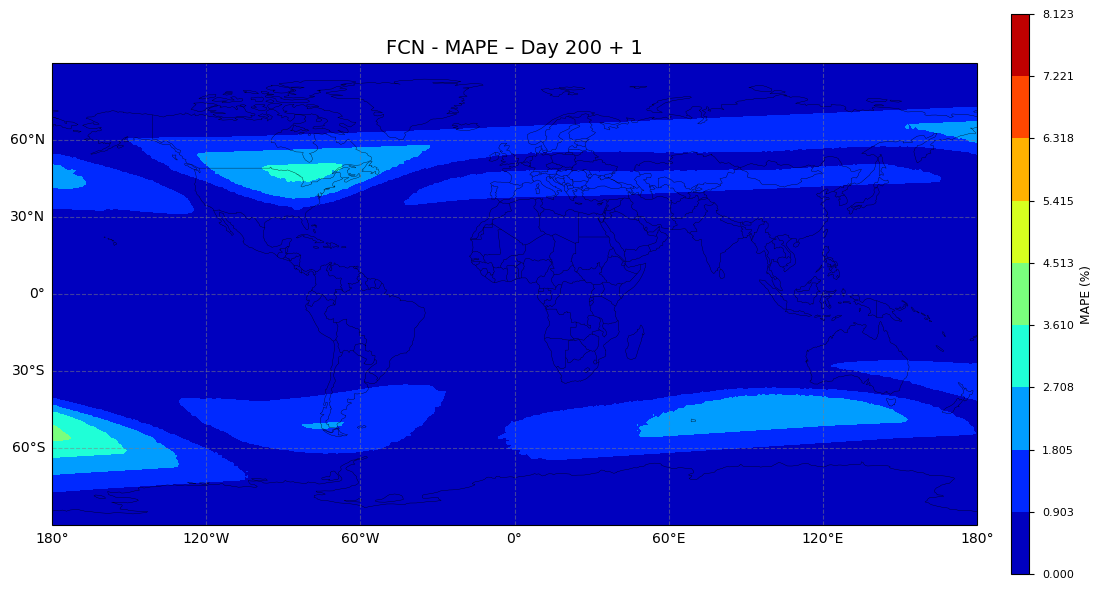

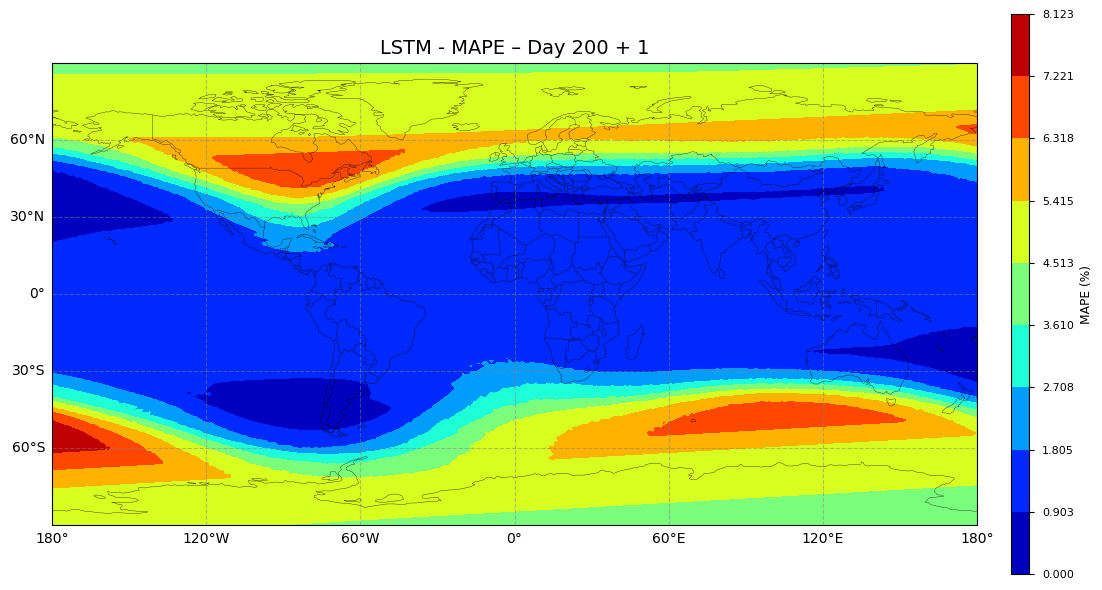

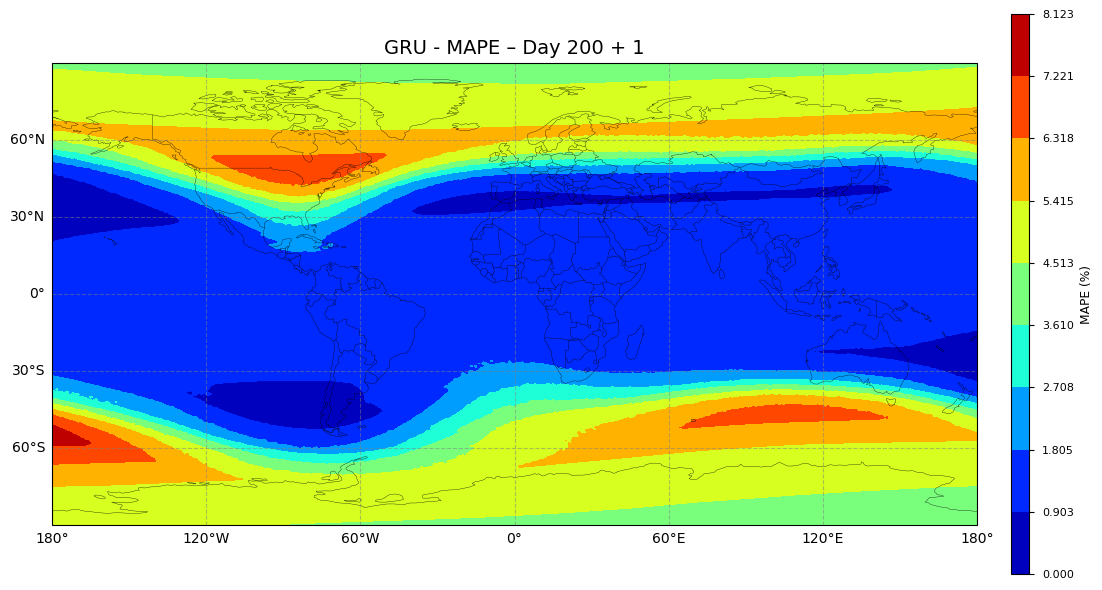

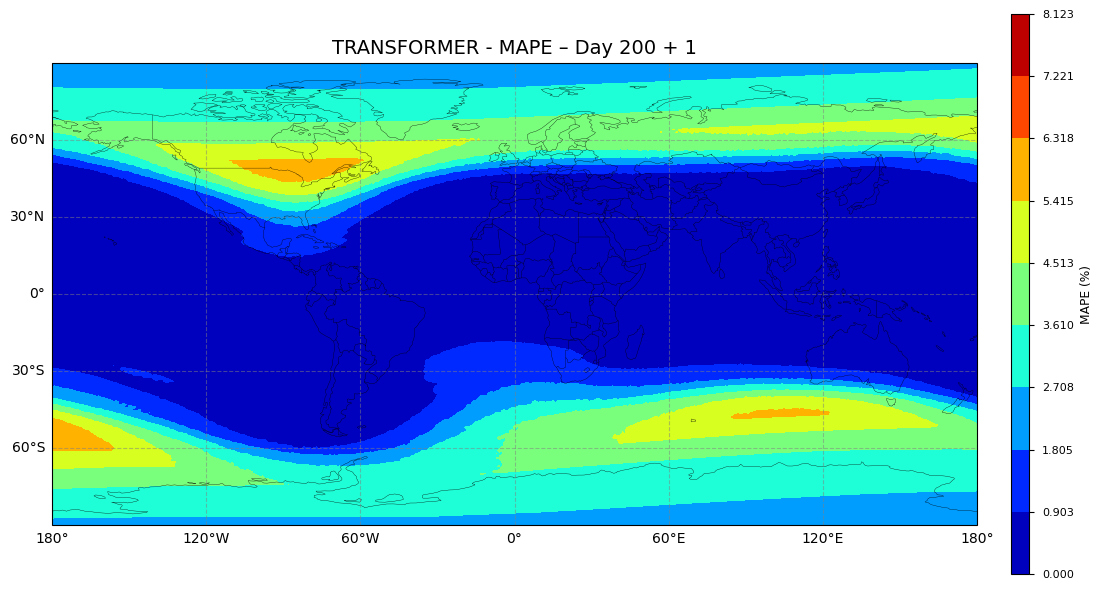

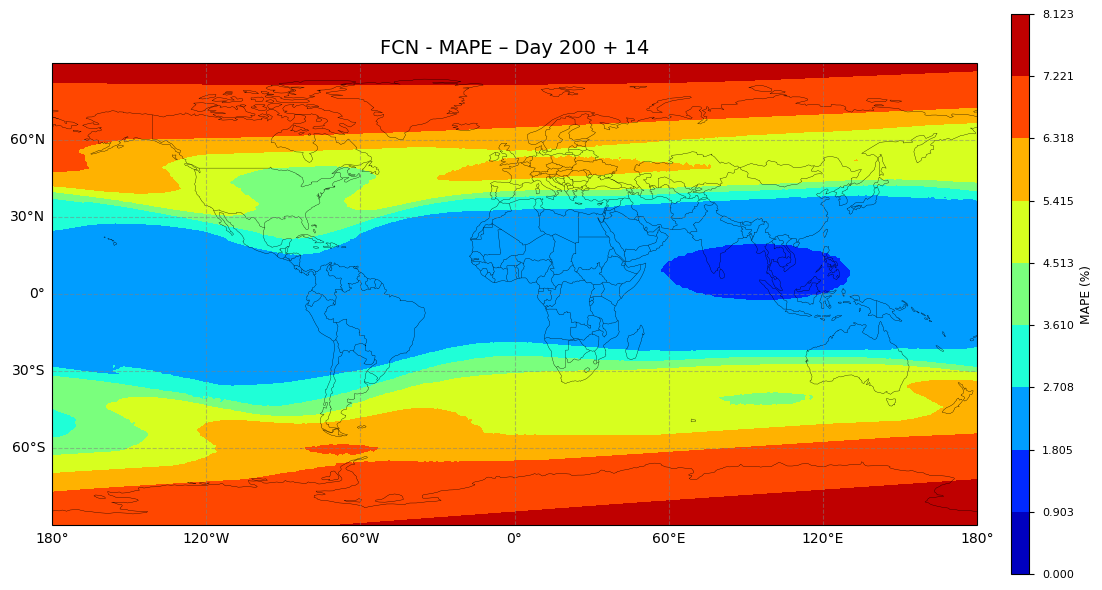

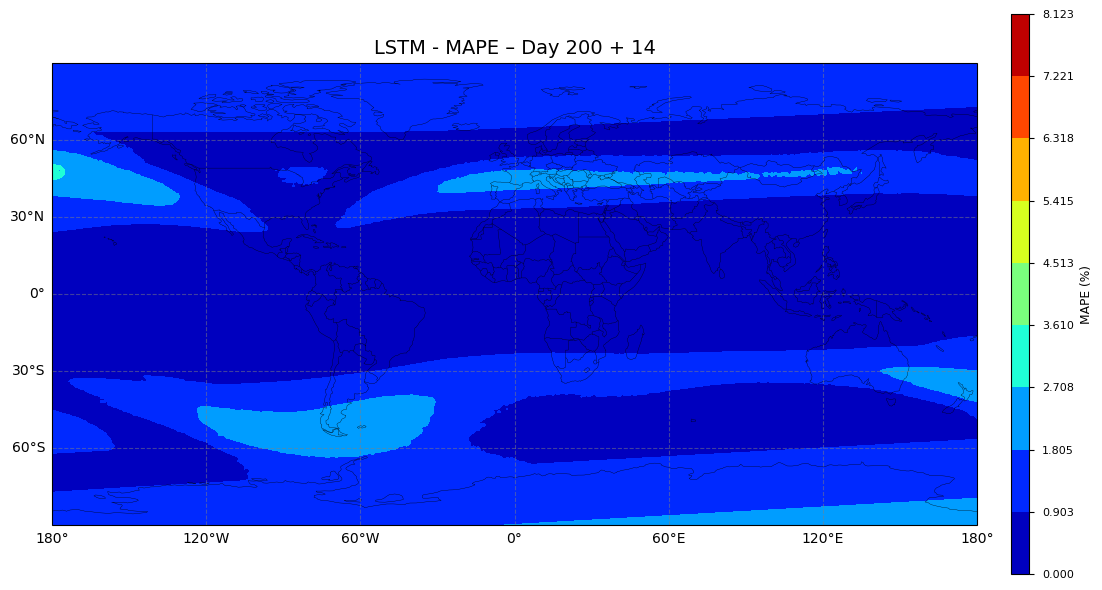

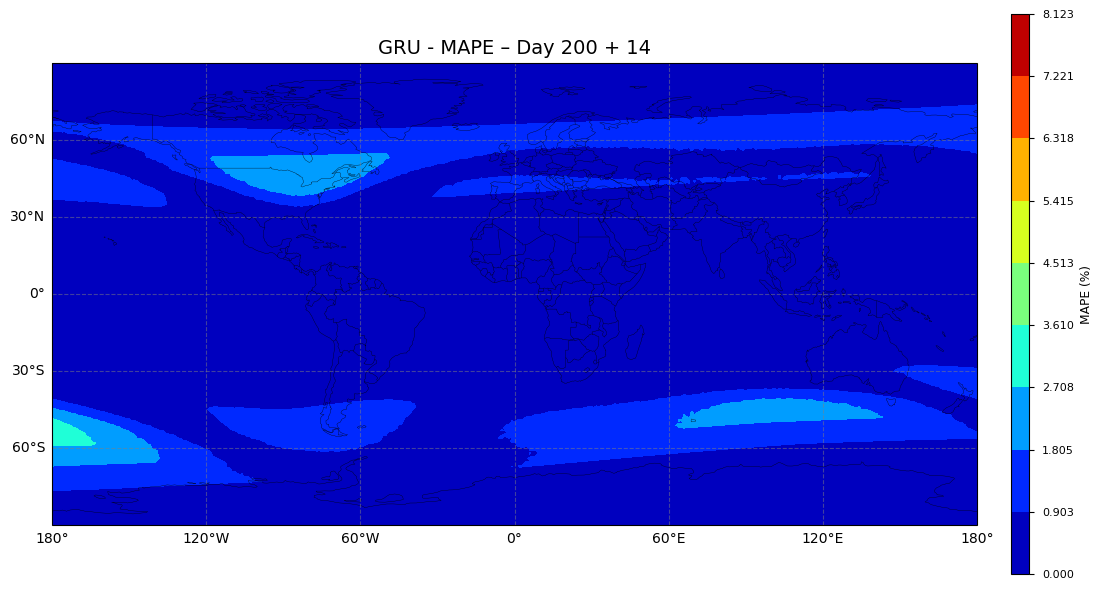

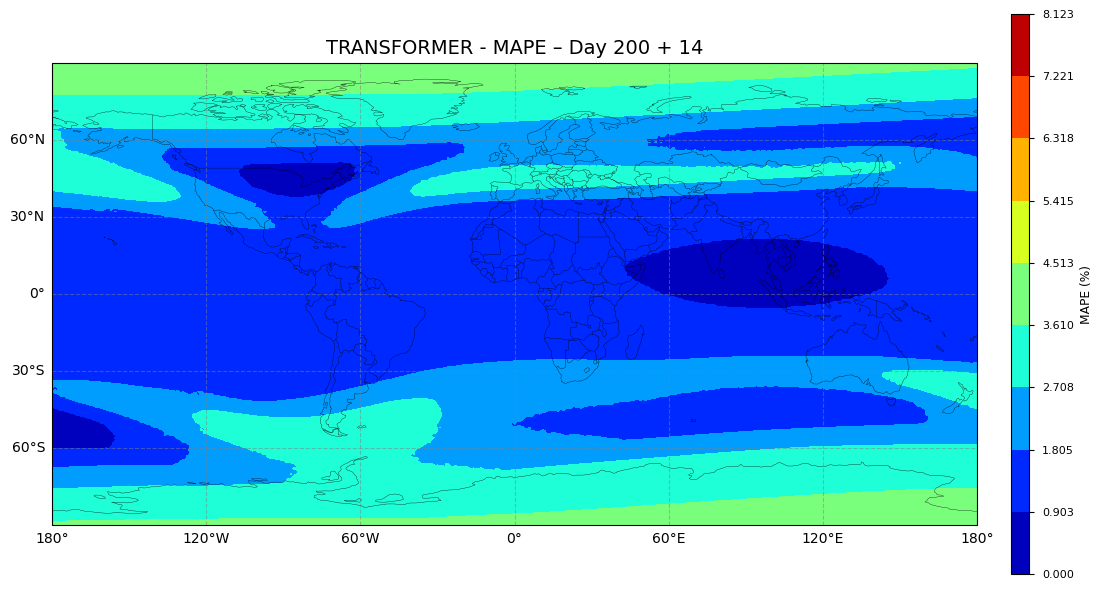

In [ ]:
save_path = '/plots'
result_path = '/inference_results'
model_types = ['fcn', 'lstm', 'gru', 'transformer']
window_size = 14
pred_window = 14
day_index = 200  # Example day index to visualize
visualize_model_predictions(model_types, window_size, pred_window, result_path, save_path, convert2dim, day_index)